## Import necessary library


In [121]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import os
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

## Get File path and load the csv data


In [122]:
from util.data_path import green_bean_price_avg_year_fix as data_file

In [123]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"]).astype(str) + "-" + long["month"].astype(str).str.zfill(2) + "-01"
)
long = long.set_index("date").sort_index()

In [124]:
# Rolling window parameters
WINDOW_SIZE = 8  # 5-year training window
FIRST_TRAIN_START = 2004  # First training window starts in 2004
LAST_AVAILABLE_YEAR = long.index.year.max()  # Get the last available year in data

print(f"Data available from {long.index.year.min()} to {LAST_AVAILABLE_YEAR}")
print(f"Using {WINDOW_SIZE}-year rolling window approach")
print(
    f"First training window: {FIRST_TRAIN_START}-{FIRST_TRAIN_START + WINDOW_SIZE - 1}"
)
print(f"Last possible prediction year: {LAST_AVAILABLE_YEAR}")

# Calculate how many windows we can create
num_windows = LAST_AVAILABLE_YEAR - (FIRST_TRAIN_START + WINDOW_SIZE - 1)
print(f"Total number of rolling windows: {num_windows}")

# Initialize lists to store results from all windows
all_forecasts = []
all_actuals = []
all_errors = []
all_window_info = []

Data available from 2004 to 2024
Using 8-year rolling window approach
First training window: 2004-2011
Last possible prediction year: 2024
Total number of rolling windows: 13


## Rolling Window Training and Prediction Approach


In [125]:
# Rolling window training and prediction
print("Starting rolling window analysis...")
print("=" * 50)

for window_idx in range(num_windows):
    # Calculate years for current window
    train_start = FIRST_TRAIN_START + window_idx
    train_end = train_start + WINDOW_SIZE - 1
    pred_year = train_end + 1

    print(f"\nWindow {window_idx + 1}/{num_windows}:")
    print(f"Training: {train_start}-{train_end} | Predicting: {pred_year}")

    # Prepare training data for current window
    train = long[(long.index.year >= train_start) & (long.index.year <= train_end)][
        "price"
    ].to_frame()

    # Get actual data for prediction year
    future = long[long.index.year == pred_year]["price"].to_frame()

    # Check if we have data for the prediction year
    if future.empty:
        print(f"No data available for prediction year {pred_year}, skipping...")
        continue

    # Scale the training data
    scaler = MinMaxScaler()
    train["scaled"] = scaler.fit_transform(train[["price"]])
    series = train["scaled"].values.astype(np.float32)

    print(f"Training data: {len(train)} months ({len(train) / 12:.1f} years)")
    print(f"Prediction data: {len(future)} months")

Starting rolling window analysis...

Window 1/13:
Training: 2004-2011 | Predicting: 2012
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 2/13:
Training: 2005-2012 | Predicting: 2013
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 3/13:
Training: 2006-2013 | Predicting: 2014
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 4/13:
Training: 2007-2014 | Predicting: 2015
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 5/13:
Training: 2008-2015 | Predicting: 2016
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 6/13:
Training: 2009-2016 | Predicting: 2017
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 7/13:
Training: 2010-2017 | Predicting: 2018
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 8/13:
Training: 2011-2018 | Predicting: 2019
Training data: 96 months (8.0 years)
Prediction data: 12 months

Window 9/13:
Training: 2012

In [126]:
# Import LSTM classes and set parameters
from util.manystep_lstm_class import SeqDataset
from util.manystep_lstm_class import LSTMRegressor

# LSTM Model Parameters
SEQ_LEN = 12  # Input sequence length (12 months)
PRED_LEN = 12  # Prediction length (12 months)
EPOCHS = 300  # Training epochs per window

print("LSTM Parameters:")
print(f"Sequence Length: {SEQ_LEN} months")
print(f"Prediction Length: {PRED_LEN} months")
print(f"Training Epochs per window: {EPOCHS}")
print("Hidden units: 32, Layers: 3")

LSTM Parameters:
Sequence Length: 12 months
Prediction Length: 12 months
Training Epochs per window: 300
Hidden units: 32, Layers: 3


In [127]:
# Create dataset and data loader for current window
train_ds = SeqDataset(series, seq_len=SEQ_LEN, pred_len=PRED_LEN)
train_loader = DataLoader(train_ds, batch_size=len(train_ds), shuffle=True)

# Initialize and train LSTM model for current window
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMRegressor(hidden=32, layers=3, pred_len=PRED_LEN).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

model.train()
for ep in range(EPOCHS):
    for seq, targ in train_loader:
        seq = seq.to(device)
        targ = targ.to(device)
        pred = model(seq)
        loss = criterion(pred, targ)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print(f"Model training completed for window {window_idx + 1}")

Model training completed for window 13


In [128]:
# Make predictions for the current window
last_window_scaled = series[-SEQ_LEN:].copy()

model.eval()
with torch.no_grad():
    x = (
        torch.tensor(last_window_scaled, dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
        .to(device)
    )
    pred_12 = model(x).cpu().numpy().reshape(-1)
    forecast_scaled = pred_12

    # Convert predictions back to original scale
    forecast_values = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).reshape(
        -1
    )

    # Create forecast series with proper dates
    months = pd.date_range(start=f"{pred_year}-01-01", periods=PRED_LEN, freq="MS")
    forecast = pd.Series(forecast_values, index=months, name="forecast_price")

    # Store results for this window
    window_info = {
        "window_idx": window_idx + 1,
        "train_start": train_start,
        "train_end": train_end,
        "pred_year": pred_year,
        "forecast": forecast,
        "actual": future["price"],
        "train_size": len(train),
    }

    all_window_info.append(window_info)
    all_forecasts.append(forecast)
    all_actuals.append(future["price"])

    # Calculate errors for this window
    error = future["price"] - forecast
    abs_error = abs(error)
    mae_window = mean_absolute_error(future["price"], forecast)

    all_errors.append(
        {
            "window": window_idx + 1,
            "pred_year": pred_year,
            "mae": mae_window,
            "error_series": error,
            "abs_error_series": abs_error,
        }
    )

    print(f"Window {window_idx + 1} completed - MAE: {mae_window:.4f}")

print("\n" + "=" * 50)
print("Rolling window analysis completed!")
print(f"Total windows processed: {len(all_window_info)}")
print(f"Years predicted: {[info['pred_year'] for info in all_window_info]}")

Window 13 completed - MAE: 2.2538

Rolling window analysis completed!
Total windows processed: 1
Years predicted: [2024]


In [129]:
# Consolidate results from all rolling windows
print("\n" + "=" * 60)
print("ROLLING WINDOW ANALYSIS SUMMARY")
print("=" * 60)

# Combine all forecasts and actuals
combined_forecasts = pd.concat(all_forecasts)
combined_actuals = pd.concat(all_actuals)

# Create comprehensive comparison dataframe
cmp = pd.concat(
    [combined_actuals.rename("actual"), combined_forecasts.rename("forecast_price")],
    axis=1,
)
cmp = cmp.dropna()  # Remove any NaN values

# Overall error analysis
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
abs_pct_error = abs_error / cmp["actual"] * 100

# Overall metrics
mae_overall = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_overall = abs_pct_error.mean()
accuracy_overall = 100 - (mae_overall / cmp["actual"].mean() * 100)

print("\nOVERALL PERFORMANCE ACROSS ALL WINDOWS:")
print(f"Total predictions made: {len(cmp)} months across {len(all_window_info)} years")
print(f"Overall MAE: {mae_overall:.6f}")
print(f"Overall MAPE: {mape_overall:.4f}%")
print(f"Overall Accuracy: {accuracy_overall:.2f}%")

# Window-by-window performance
print("\nWINDOW-BY-WINDOW PERFORMANCE:")
print(f"{'Window':<8} {'Year':<6} {'MAE':<12} {'Train Period':<15}")
print("-" * 50)
for i, err_info in enumerate(all_errors):
    window_info = all_window_info[i]
    train_period = f"{window_info['train_start']}-{window_info['train_end']}"
    print(
        f"{err_info['window']:<8} {err_info['pred_year']:<6} {err_info['mae']:<12.6f} {train_period:<15}"
    )

# Calculate average MAE across all windows
avg_mae = np.mean([err["mae"] for err in all_errors])
print(f"\nAverage MAE across all windows: {avg_mae:.6f}")
print(f"MAE Standard Deviation: {np.std([err['mae'] for err in all_errors]):.6f}")


ROLLING WINDOW ANALYSIS SUMMARY

OVERALL PERFORMANCE ACROSS ALL WINDOWS:
Total predictions made: 12 months across 1 years
Overall MAE: 2.253770
Overall MAPE: 8.1511%
Overall Accuracy: 91.36%

WINDOW-BY-WINDOW PERFORMANCE:
Window   Year   MAE          Train Period   
--------------------------------------------------
13       2024   2.253770     2016-2023      

Average MAE across all windows: 2.253770
MAE Standard Deviation: 0.000000


## Save the Forecasted Price LSTM Model


In [130]:
from util.data_path import LSTM_5T_for
from datetime import datetime

In [131]:
# Verify rolling window training data and results
print("Rolling Window Analysis Summary:")
print(f"Number of windows: {len(all_window_info)}")
print(f"Total predictions: {len(cmp)} months")
print(f"Years covered: {cmp.index.year.min()} to {cmp.index.year.max()}")
print(f"Average training period per window: {WINDOW_SIZE} years")

print("\nWindow details:")
for info in all_window_info:
    train_months = info["train_size"]
    pred_months = len(info["forecast"])
    print(
        f"  Window {info['window_idx']}: Train {info['train_start']}-{info['train_end']} ({train_months} months) -> Predict {info['pred_year']} ({pred_months} months)"
    )

Rolling Window Analysis Summary:
Number of windows: 1
Total predictions: 12 months
Years covered: 2024 to 2024
Average training period per window: 8 years

Window details:
  Window 13: Train 2016-2023 (96 months) -> Predict 2024 (12 months)


In [132]:
# Save rolling window forecast results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_rolling_window_forecast.txt"
filepath = LSTM_5T_for / filename

# Save comprehensive forecast data to text file
with open(filepath, "w", encoding="utf-8") as f:
    f.write(
        f"LSTM Rolling Window Forecast Results for {data_file.parent.name.capitalize()} Prices - {timestamp}\n"
    )
    f.write("=" * 80 + "\n\n")

    f.write("Rolling Window Configuration:\n")
    f.write("-" * 30 + "\n")
    f.write(f"Window Size: {WINDOW_SIZE} years\n")
    f.write(f"Total Windows: {len(all_window_info)}\n")
    f.write(
        f"First Training Period: {all_window_info[0]['train_start']}-{all_window_info[0]['train_end']}\n"
    )
    f.write(
        f"Last Training Period: {all_window_info[-1]['train_start']}-{all_window_info[-1]['train_end']}\n"
    )
    f.write(f"Prediction Years: {[info['pred_year'] for info in all_window_info]}\n\n")

    # Window-by-window results
    for i, info in enumerate(all_window_info):
        f.write(
            f"Window {info['window_idx']} - Training: {info['train_start']}-{info['train_end']}, Predicting: {info['pred_year']}\n"
        )
        f.write("-" * 50 + "\n")
        for date, price in info["forecast"].items():
            f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")
        f.write(f"\nWindow {info['window_idx']} Statistics:\n")
        f.write(
            f"Mean: {info['forecast'].mean():.2f}, Min: {info['forecast'].min():.2f}, Max: {info['forecast'].max():.2f}\n\n"
        )

    f.write("Overall Consolidated Statistics:\n")
    f.write("-" * 30 + "\n")
    f.write(f"Total Predictions: {len(combined_forecasts)} months\n")
    f.write(f"Overall Mean Price: {combined_forecasts.mean():.2f}\n")
    f.write(f"Overall Min Price: {combined_forecasts.min():.2f}\n")
    f.write(f"Overall Max Price: {combined_forecasts.max():.2f}\n")
    f.write(f"Overall Standard Deviation: {combined_forecasts.std():.2f}\n")

print(f"Rolling window forecast results saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Rolling window forecast results saved to: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\forecast_price\LSTM-5T\green_bean_rolling_window_forecast.txt
File size: 964 bytes


## Compare The Error of a predicted data in a table format


In [133]:
# Comprehensive error analysis for rolling window results
print("\n=== ROLLING WINDOW ERROR ANALYSIS ===")

# Overall consolidated errors
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
abs_pct_error = abs_error / cmp["actual"] * 100
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_lstm = abs_pct_error.mean()

print("\nCONSOLIDATED RESULTS ACROSS ALL WINDOWS:")
print(f"Total predictions: {len(cmp)} months")
print(f"Overall MAE: {mae_lstm:.6f}")
print(f"Overall MAPE: {mape_lstm:.4f}%")
print(f"Overall Accuracy: {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}%")

# Window-by-window detailed analysis
print("\nWINDOW-BY-WINDOW ERROR ANALYSIS:")
print(
    f"{'Window':<8} {'Year':<6} {'MAE':<12} {'MAPE':<12} {'Accuracy':<10} {'Train Period':<15}"
)
print("-" * 75)

window_maes = []
window_mapes = []
window_accuracies = []

for i, info in enumerate(all_window_info):
    actual_vals = info["actual"]
    forecast_vals = info["forecast"]

    window_error = actual_vals - forecast_vals
    window_abs_error = abs(window_error)
    window_mae = mean_absolute_error(actual_vals, forecast_vals)
    window_mape = (window_abs_error / actual_vals * 100).mean()
    window_accuracy = 100 - (window_mae / actual_vals.mean() * 100)

    window_maes.append(window_mae)
    window_mapes.append(window_mape)
    window_accuracies.append(window_accuracy)

    train_period = f"{info['train_start']}-{info['train_end']}"
    print(
        f"{info['window_idx']:<8} {info['pred_year']:<6} {window_mae:<12.6f} {window_mape:<12.4f}% {window_accuracy:<10.2f}% {train_period:<15}"
    )

# Cross-window statistics
print("\nCROSS-WINDOW STATISTICS:")
print(f"Average MAE across windows: {np.mean(window_maes):.6f}")
print(f"MAE Standard Deviation: {np.std(window_maes):.6f}")
print(
    f"Best Window MAE: {np.min(window_maes):.6f} (Window {np.argmin(window_maes) + 1})"
)
print(
    f"Worst Window MAE: {np.max(window_maes):.6f} (Window {np.argmax(window_maes) + 1})"
)
print(f"Average MAPE across windows: {np.mean(window_mapes):.4f}%")
print(f"Average Accuracy across windows: {np.mean(window_accuracies):.2f}%")

# Monthly breakdown for consolidated results
print("\nCONSOLIDATED MONTHLY ERRORS:")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,
    }
)
print(error_df.round(4))


=== ROLLING WINDOW ERROR ANALYSIS ===

CONSOLIDATED RESULTS ACROSS ALL WINDOWS:
Total predictions: 12 months
Overall MAE: 2.253770
Overall MAPE: 8.1511%
Overall Accuracy: 91.36%

WINDOW-BY-WINDOW ERROR ANALYSIS:
Window   Year   MAE          MAPE         Accuracy   Train Period   
---------------------------------------------------------------------------
13       2024   2.253770     8.1511      % 91.36     % 2016-2023      

CROSS-WINDOW STATISTICS:
Average MAE across windows: 2.253770
MAE Standard Deviation: 0.000000
Best Window MAE: 2.253770 (Window 1)
Worst Window MAE: 2.253770 (Window 1)
Average MAPE across windows: 8.1511%
Average Accuracy across windows: 91.36%

CONSOLIDATED MONTHLY ERRORS:
            actual   forecast   error  abs_error  abs_pct_error
2024-01-01   25.11  22.170099  2.9399     2.9399        11.7080
2024-02-01   25.00  22.756500  2.2435     2.2435         8.9742
2024-03-01   26.34  23.563801  2.7762     2.7762        10.5398
2024-04-01   25.62  23.238001  2.3820

## Plot The predicted data compare to an actual data



=== PEAK ANALYSIS ===
Actual Peak: 31.00 at 2024-09
Forecast Peak: 25.63 at 2024-08
Time Difference: 1 months
Price Difference: 5.37 (17.34%)


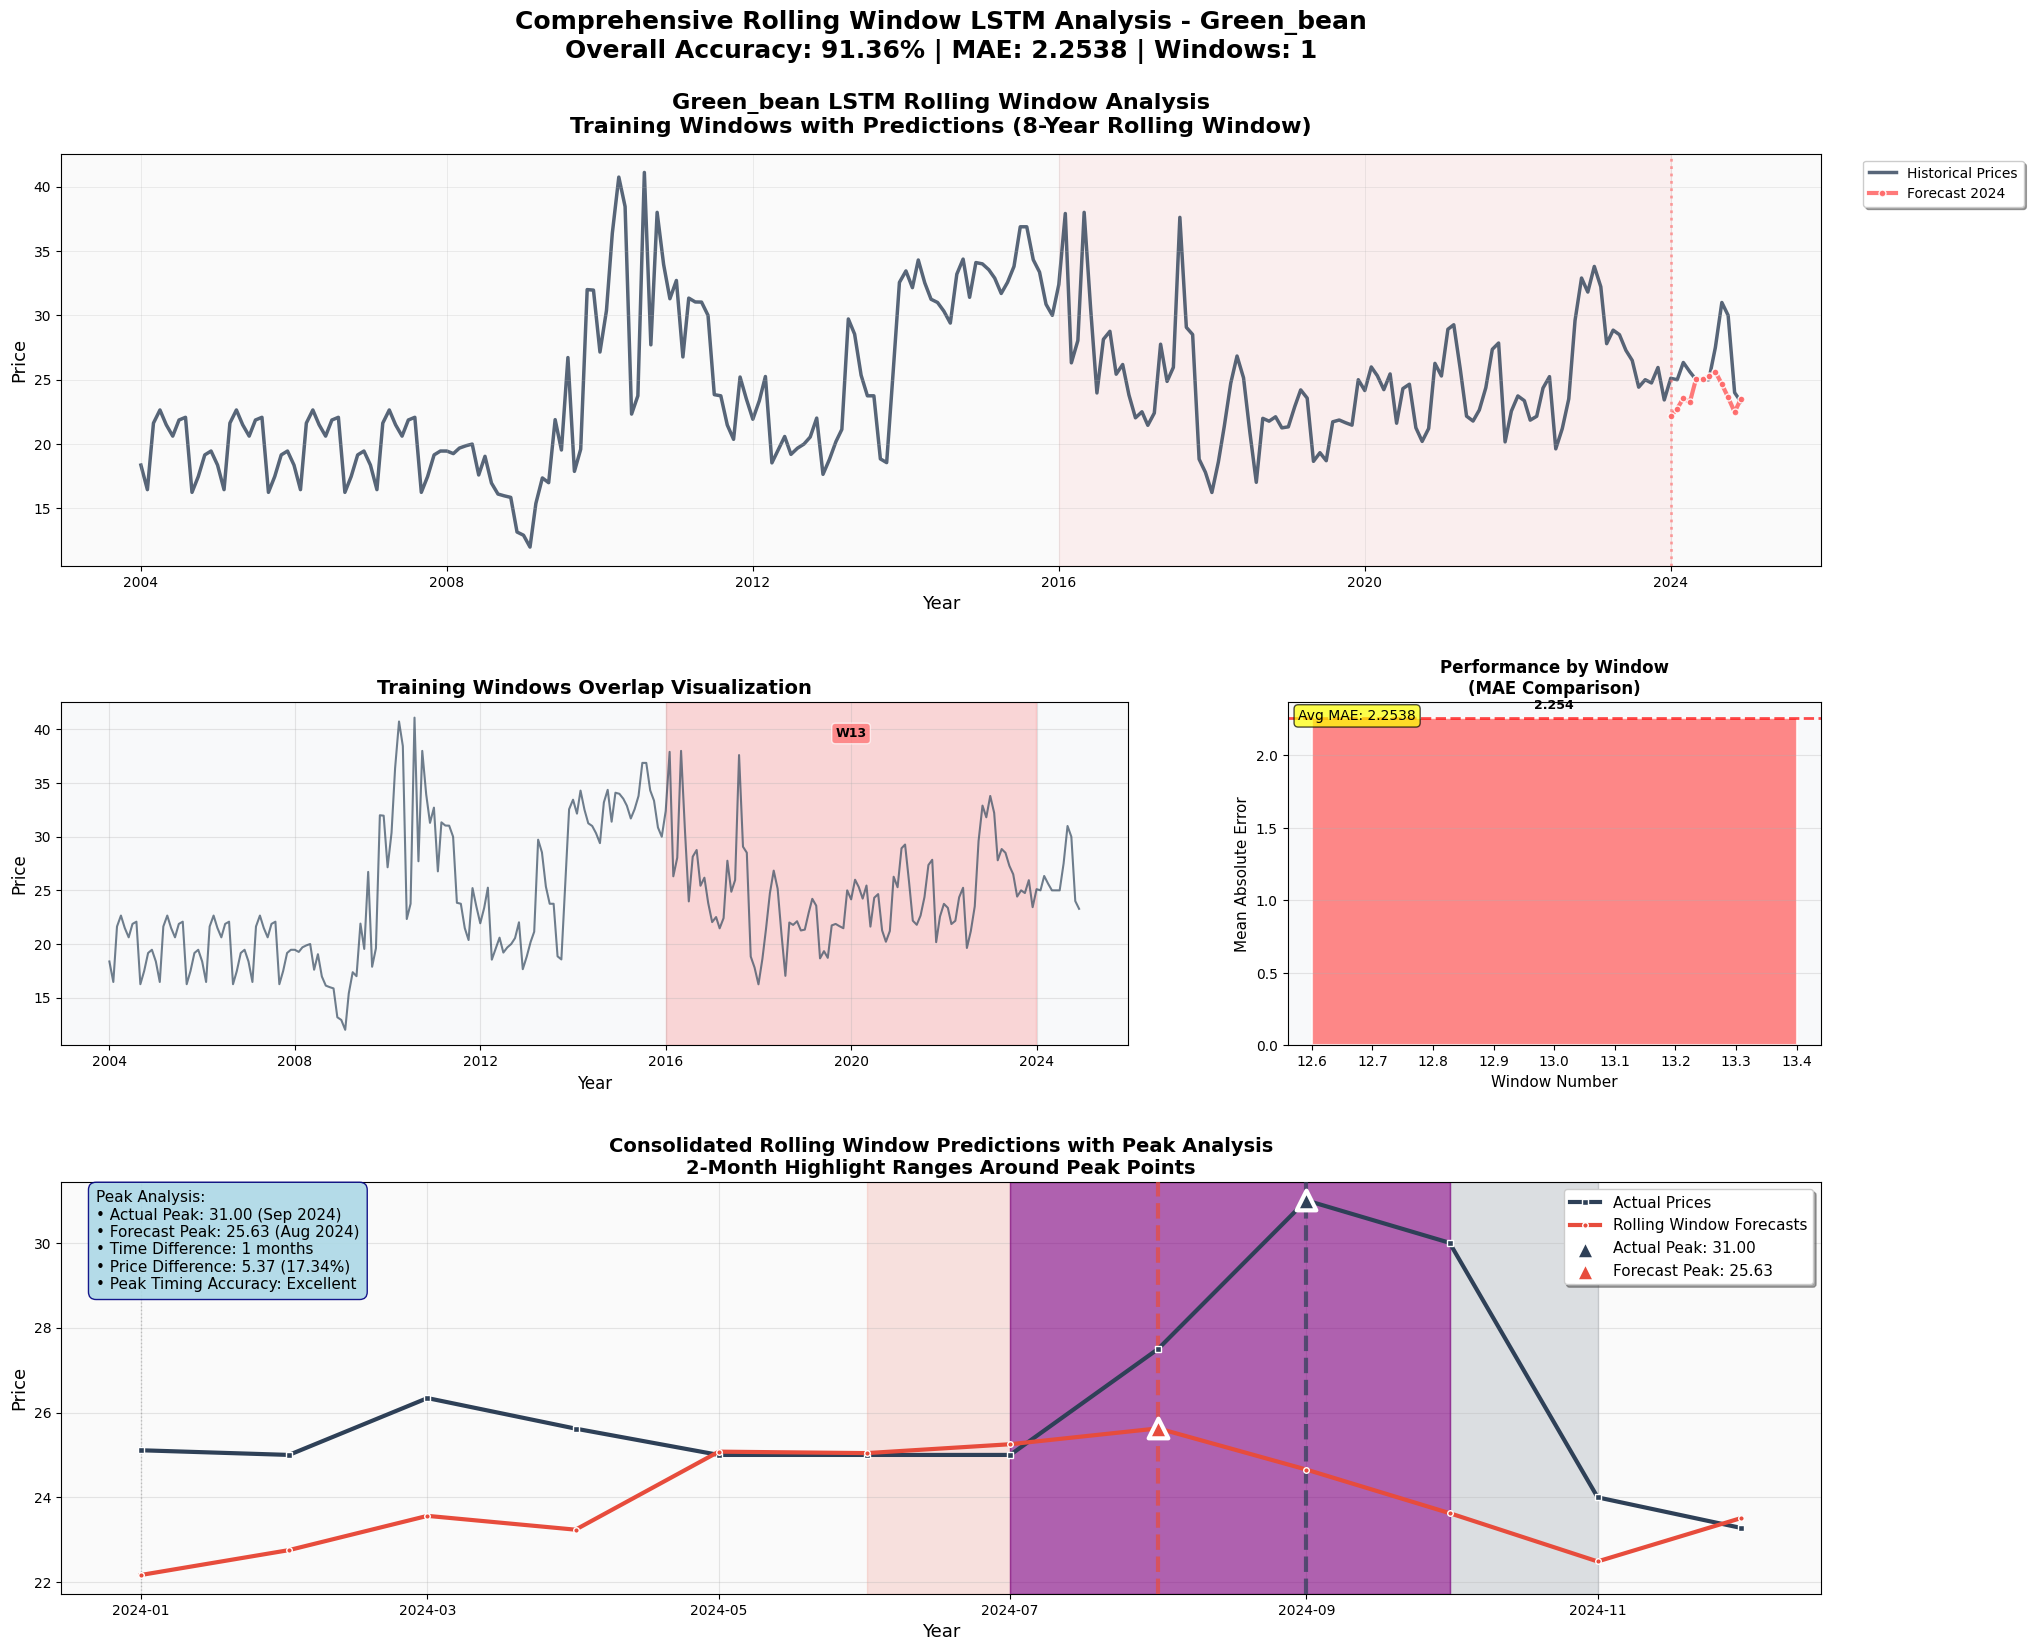


DETAILED PEAK ANALYSIS REPORT

PEAK IDENTIFICATION:
Metric               Actual          Forecast        Difference     
-----------------------------------------------------------------
Peak Value           31.00           25.63           5.37           
Peak Date            2024-09         2024-08         1 months
Peak Day of Year     245             214             31             

PEAK ANALYSIS METRICS:
• Relative Error: 17.34%
• Temporal Accuracy: 91.7%
• Peak Direction: Actual Higher
• Actual Peak Season: Q3 (September)
• Forecast Peak Season: Q3 (August)
• Seasonal Match: Yes

CONTEXT ANALYSIS (±3 months around peaks):
• Actual Peak Context Volatility: 3.017
• Forecast Peak Context Volatility: 1.101
• Model Peak Smoothness: High


In [134]:
# Enhanced Rolling Window Analysis with Peak Detection
plt.style.use("default")
fig = plt.figure(figsize=(20, 18))

# Create a sophisticated 4-panel layout with better spacing
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.2, 1, 1.2],
    width_ratios=[2, 1],
    hspace=0.35,  # Increased vertical spacing
    wspace=0.20,  # Increased horizontal spacing
    top=0.88,  # Leave space for main title
    bottom=0.08,  # Space at bottom
    left=0.06,  # Space on left
    right=0.94,  # Space on right for legends
)

# Color palette for windows
colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#96CEB4",
    "#FFEAA7",
    "#DDA0DD",
    "#98D8C8",
    "#F7DC6F",
    "#BB8FCE",
    "#85C1E9",
]

# === Panel 1: Main Predictions Overview (top left, spans 2 columns) ===
ax_main = fig.add_subplot(gs[0, :])

# Plot historical data
ax_main.plot(
    long.index,
    long["price"],
    label="Historical Prices",
    color="#2E4057",
    linewidth=2.5,
    alpha=0.8,
    zorder=1,
)

# Plot training windows as subtle background
for i, info in enumerate(all_window_info):
    train_start_date = pd.Timestamp(f"{info['train_start']}-01-01")
    train_end_date = pd.Timestamp(f"{info['train_end']}-12-31")
    ax_main.axvspan(
        train_start_date,
        train_end_date,
        alpha=0.08,
        color=colors[i % len(colors)],
        zorder=0,
    )

# Plot forecasts with enhanced styling
for i, info in enumerate(all_window_info):
    color = colors[i % len(colors)]
    # Main forecast line
    ax_main.plot(
        info["forecast"].index,
        info["forecast"],
        color=color,
        linewidth=3,
        alpha=0.9,
        marker="o",
        markersize=5,
        markeredgecolor="white",
        markeredgewidth=1,
        label=f"Forecast {info['pred_year']}",
        zorder=3,
    )

    # Prediction start marker
    ax_main.axvline(
        x=pd.Timestamp(f"{info['pred_year']}-01-01"),
        color=color,
        linestyle=":",
        alpha=0.6,
        linewidth=2,
        zorder=2,
    )

ax_main.set_title(
    f"{data_file.parent.name.capitalize()} LSTM Rolling Window Analysis\n"
    f"Training Windows with Predictions ({WINDOW_SIZE}-Year Rolling Window)",
    fontsize=16,
    fontweight="bold",
    pad=15,  # Reduced padding since we have more space above
)
ax_main.set_xlabel("Year", fontsize=13, fontweight="medium")
ax_main.set_ylabel("Price", fontsize=13, fontweight="medium")
ax_main.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True,
)
ax_main.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
ax_main.set_facecolor("#FAFAFA")

# === Panel 2: Training Windows Highlight (middle left) ===
ax_windows = fig.add_subplot(gs[1, 0])

# Plot base price line
ax_windows.plot(long.index, long["price"], color="#34495E", linewidth=1.5, alpha=0.7)

# Highlight training windows with different intensities
for i, info in enumerate(all_window_info):
    train_start_date = pd.Timestamp(f"{info['train_start']}-01-01")
    train_end_date = pd.Timestamp(f"{info['train_end']}-12-31")

    # Create overlapping effect with alpha blending
    ax_windows.axvspan(
        train_start_date,
        train_end_date,
        alpha=0.25,
        color=colors[i % len(colors)],
        label=f"Window {info['window_idx']}: {info['train_start']}-{info['train_end']}",
    )

    # Add window labels
    mid_date = train_start_date + (train_end_date - train_start_date) / 2
    ax_windows.annotate(
        f"W{info['window_idx']}",
        xy=(mid_date, long["price"].loc[train_start_date:train_end_date].max()),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor=colors[i % len(colors)],
            alpha=0.7,
            edgecolor="white",
        ),
    )

ax_windows.set_title(
    "Training Windows Overlap Visualization", fontsize=14, fontweight="bold"
)
ax_windows.set_xlabel("Year", fontsize=12)
ax_windows.set_ylabel("Price", fontsize=12)
ax_windows.grid(True, alpha=0.3)
ax_windows.set_facecolor("#F8F9FA")

# === Panel 3: Window Performance Metrics (middle right) ===
ax_metrics = fig.add_subplot(gs[1, 1])

# Create performance comparison
windows_num = [info["window_idx"] for info in all_window_info]
pred_years = [info["pred_year"] for info in all_window_info]

# MAE bars with gradient effect
bars = ax_metrics.bar(
    windows_num,
    window_maes,
    color=[colors[i % len(colors)] for i in range(len(windows_num))],
    alpha=0.8,
    edgecolor="white",
    linewidth=1.5,
)

# Add value labels on bars
for i, (bar, mae) in enumerate(zip(bars, window_maes)):
    height = bar.get_height()
    ax_metrics.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.02,
        f"{mae:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax_metrics.set_title(
    "Performance by Window\n(MAE Comparison)", fontsize=12, fontweight="bold"
)
ax_metrics.set_xlabel("Window Number", fontsize=11)
ax_metrics.set_ylabel("Mean Absolute Error", fontsize=11)
ax_metrics.grid(True, alpha=0.3, axis="y")
ax_metrics.set_facecolor("#F8F9FA")

# Add average line
avg_mae = np.mean(window_maes)
ax_metrics.axhline(y=avg_mae, color="red", linestyle="--", alpha=0.7, linewidth=2)
ax_metrics.text(
    0.02,
    0.98,
    f"Avg MAE: {avg_mae:.4f}",
    transform=ax_metrics.transAxes,
    bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.7),
    fontsize=10,
    va="top",
)

# === Panel 4: Consolidated Predictions with Peak Analysis (bottom, spans 2 columns) ===
ax_consolidated = fig.add_subplot(gs[2, :])

# Plot actual vs forecast
actual_line = ax_consolidated.plot(
    cmp.index,
    cmp["actual"],
    label="Actual Prices",
    color="#2E4057",
    linewidth=3,
    marker="s",
    markersize=4,
    markeredgecolor="white",
    markeredgewidth=1,
    zorder=4,
)

forecast_line = ax_consolidated.plot(
    cmp.index,
    cmp["forecast_price"],
    label="Rolling Window Forecasts",
    color="#E74C3C",
    linewidth=3,
    marker="o",
    markersize=4,
    markeredgecolor="white",
    markeredgewidth=1,
    zorder=4,
)

# === PEAK ANALYSIS ===
# Find peak points
actual_peak_idx = cmp["actual"].idxmax()
forecast_peak_idx = cmp["forecast_price"].idxmax()
actual_peak_value = cmp["actual"].max()
forecast_peak_value = cmp["forecast_price"].max()

print("\n=== PEAK ANALYSIS ===")
print(f"Actual Peak: {actual_peak_value:.2f} at {actual_peak_idx.strftime('%Y-%m')}")
print(
    f"Forecast Peak: {forecast_peak_value:.2f} at {forecast_peak_idx.strftime('%Y-%m')}"
)

# Calculate time difference in months
time_diff_months = abs(
    (actual_peak_idx.year - forecast_peak_idx.year) * 12
    + (actual_peak_idx.month - forecast_peak_idx.month)
)
price_diff = abs(actual_peak_value - forecast_peak_value)
price_diff_pct = (price_diff / actual_peak_value) * 100

print(f"Time Difference: {time_diff_months} months")
print(f"Price Difference: {price_diff:.2f} ({price_diff_pct:.2f}%)")

# Add peak markers with enhanced visualization
ax_consolidated.scatter(
    actual_peak_idx,
    actual_peak_value,
    color="#2E4057",
    s=200,
    marker="^",
    edgecolor="white",
    linewidth=3,
    zorder=6,
    label=f"Actual Peak: {actual_peak_value:.2f}",
)

ax_consolidated.scatter(
    forecast_peak_idx,
    forecast_peak_value,
    color="#E74C3C",
    s=200,
    marker="^",
    edgecolor="white",
    linewidth=3,
    zorder=6,
    label=f"Forecast Peak: {forecast_peak_value:.2f}",
)

# Add vertical lines at peaks
ax_consolidated.axvline(
    x=actual_peak_idx, color="#2E4057", linestyle="--", alpha=0.7, linewidth=3, zorder=3
)
ax_consolidated.axvline(
    x=forecast_peak_idx,
    color="#E74C3C",
    linestyle="--",
    alpha=0.7,
    linewidth=3,
    zorder=3,
)


# Create 2-month highlight ranges around peaks
def add_peak_highlight(ax, peak_date, peak_value, color, alpha_base=0.15):
    start_date = peak_date - pd.DateOffset(months=2)
    end_date = peak_date + pd.DateOffset(months=2)

    # Find overlap region for color intensity
    other_peak = forecast_peak_idx if peak_date == actual_peak_idx else actual_peak_idx
    other_start = other_peak - pd.DateOffset(months=2)
    other_end = other_peak + pd.DateOffset(months=2)

    # Check for overlap
    overlap_start = max(start_date, other_start)
    overlap_end = min(end_date, other_end)

    if overlap_start < overlap_end:
        # Non-overlapping regions
        if start_date < other_start:
            ax.axvspan(start_date, other_start, alpha=alpha_base, color=color, zorder=1)
        if end_date > other_end:
            ax.axvspan(other_end, end_date, alpha=alpha_base, color=color, zorder=1)
        # Overlapping region with higher intensity
        ax.axvspan(
            overlap_start, overlap_end, alpha=alpha_base * 2.5, color="purple", zorder=2
        )
    else:
        # No overlap
        ax.axvspan(start_date, end_date, alpha=alpha_base, color=color, zorder=1)


# Add highlights
add_peak_highlight(ax_consolidated, actual_peak_idx, actual_peak_value, "#2E4057")
add_peak_highlight(ax_consolidated, forecast_peak_idx, forecast_peak_value, "#E74C3C")

# Add peak analysis text box
peak_analysis_text = (
    f"Peak Analysis:\n"
    f"• Actual Peak: {actual_peak_value:.2f} ({actual_peak_idx.strftime('%b %Y')})\n"
    f"• Forecast Peak: {forecast_peak_value:.2f} ({forecast_peak_idx.strftime('%b %Y')})\n"
    f"• Time Difference: {time_diff_months} months\n"
    f"• Price Difference: {price_diff:.2f} ({price_diff_pct:.2f}%)\n"
    f"• Peak Timing Accuracy: {'Excellent' if time_diff_months <= 2 else 'Good' if time_diff_months <= 6 else 'Needs Improvement'}"
)

ax_consolidated.text(
    0.02,
    0.98,
    peak_analysis_text,
    transform=ax_consolidated.transAxes,
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.9, edgecolor="navy"
    ),
    fontsize=11,
    va="top",
    fontweight="medium",
)

# Mark prediction year boundaries
for info in all_window_info:
    ax_consolidated.axvline(
        x=pd.Timestamp(f"{info['pred_year']}-01-01"),
        color="gray",
        linestyle=":",
        alpha=0.4,
        linewidth=1,
    )

ax_consolidated.set_title(
    "Consolidated Rolling Window Predictions with Peak Analysis\n"
    "2-Month Highlight Ranges Around Peak Points",
    fontsize=14,
    fontweight="bold",
)
ax_consolidated.set_xlabel("Year", fontsize=13)
ax_consolidated.set_ylabel("Price", fontsize=13)
ax_consolidated.legend(
    loc="upper right", fontsize=11, frameon=True, fancybox=True, shadow=True
)
ax_consolidated.grid(True, alpha=0.3)
ax_consolidated.set_facecolor("#FAFAFA")

# Add overall statistics with proper spacing
fig.suptitle(
    f"Comprehensive Rolling Window LSTM Analysis - {data_file.parent.name.capitalize()}\n"
    f"Overall Accuracy: {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}% | "
    f"MAE: {mae_lstm:.4f} | Windows: {len(all_window_info)}",
    fontsize=18,
    fontweight="bold",
    y=0.96,  # Move title down slightly to avoid overlap
)

# Adjust layout with proper spacing - fix tight_layout warning
plt.subplots_adjust(
    top=0.88,  # More space for main title
    bottom=0.08,  # Space at bottom
    left=0.06,  # Space on left
    right=0.94,  # Space on right for legends
    hspace=0.35,  # Increased vertical space between subplots
    wspace=0.20,  # Horizontal space between subplots
)
plt.show()

# === DETAILED PEAK ANALYSIS OUTPUT ===
print("\n" + "=" * 80)
print("DETAILED PEAK ANALYSIS REPORT")
print("=" * 80)

print("\nPEAK IDENTIFICATION:")
print(f"{'Metric':<20} {'Actual':<15} {'Forecast':<15} {'Difference':<15}")
print("-" * 65)
print(
    f"{'Peak Value':<20} {actual_peak_value:<15.2f} {forecast_peak_value:<15.2f} {price_diff:<15.2f}"
)
print(
    f"{'Peak Date':<20} {actual_peak_idx.strftime('%Y-%m'):<15} {forecast_peak_idx.strftime('%Y-%m'):<15} {time_diff_months} months"
)
print(
    f"{'Peak Day of Year':<20} {actual_peak_idx.dayofyear:<15} {forecast_peak_idx.dayofyear:<15} {abs(actual_peak_idx.dayofyear - forecast_peak_idx.dayofyear):<15}"
)

print("\nPEAK ANALYSIS METRICS:")
print(f"• Relative Error: {price_diff_pct:.2f}%")
print(f"• Temporal Accuracy: {100 - min(100, (time_diff_months / 12) * 100):.1f}%")
print(
    f"• Peak Direction: {'Forecast Higher' if forecast_peak_value > actual_peak_value else 'Actual Higher'}"
)

# Seasonal analysis
actual_season = "Q" + str((actual_peak_idx.month - 1) // 3 + 1)
forecast_season = "Q" + str((forecast_peak_idx.month - 1) // 3 + 1)
print(f"• Actual Peak Season: {actual_season} ({actual_peak_idx.strftime('%B')})")
print(f"• Forecast Peak Season: {forecast_season} ({forecast_peak_idx.strftime('%B')})")
print(f"• Seasonal Match: {'Yes' if actual_season == forecast_season else 'No'}")

# Context analysis
context_window = 3  # months around peak
actual_context = cmp.loc[
    actual_peak_idx - pd.DateOffset(months=context_window) : actual_peak_idx
    + pd.DateOffset(months=context_window),
    "actual",
]
forecast_context = cmp.loc[
    forecast_peak_idx - pd.DateOffset(months=context_window) : forecast_peak_idx
    + pd.DateOffset(months=context_window),
    "forecast_price",
]

print(f"\nCONTEXT ANALYSIS (±{context_window} months around peaks):")
print(f"• Actual Peak Context Volatility: {actual_context.std():.3f}")
print(f"• Forecast Peak Context Volatility: {forecast_context.std():.3f}")
print(
    f"• Model Peak Smoothness: {'High' if forecast_context.std() < actual_context.std() else 'Low'}"
)

print("=" * 80)

## Save the model Error Analysis to a file


In [135]:
from util.data_path import LSTM_5T_err

In [136]:
crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = LSTM_5T_err / filename

In [137]:
# Save comprehensive rolling window error analysis
crop_name = data_file.parent.name
filename = f"{crop_name}_rolling_window_error_metrics.txt"
filepath = LSTM_5T_err / filename

# Calculate consolidated metrics
mae_value = mae_lstm
mape_value = mape_lstm
accuracy = 100 - (mae_lstm / cmp["actual"].mean() * 100)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save comprehensive metrics to text file
with open(filepath, "w", encoding="utf-8") as f:
    f.write(
        f"LSTM Rolling Window Model Evaluation for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 80 + "\n\n")

    f.write("Rolling Window Configuration:\n")
    f.write("-" * 30 + "\n")
    f.write(f"Window Size: {WINDOW_SIZE} years\n")
    f.write(f"Total Windows Processed: {len(all_window_info)}\n")
    f.write(
        f"LSTM Parameters: SEQ_LEN={SEQ_LEN}, PRED_LEN={PRED_LEN}, EPOCHS={EPOCHS}\n"
    )
    f.write("Model Architecture: 32 hidden units, 3 layers\n\n")

    f.write("Overall Consolidated Metrics:\n")
    f.write("-" * 30 + "\n")
    f.write(
        f"Total Predictions: {len(cmp)} months across {len(all_window_info)} years\n"
    )
    f.write(f"Overall Mean Absolute Error (MAE): {mae_value:.6f}\n")
    f.write(f"Overall Mean Absolute Percentage Error (MAPE): {mape_value:.4f}%\n")
    f.write(f"Overall Model Accuracy: {accuracy:.2f}%\n\n")

    f.write("Window-by-Window Performance:\n")
    f.write("-" * 40 + "\n")
    f.write(
        f"{'Window':<8} {'Year':<6} {'MAE':<12} {'MAPE':<12} {'Accuracy':<10} {'Train Period':<15}\n"
    )
    f.write("-" * 75 + "\n")

    for i, info in enumerate(all_window_info):
        actual_vals = info["actual"]
        forecast_vals = info["forecast"]
        window_mae = mean_absolute_error(actual_vals, forecast_vals)
        window_abs_error = abs(actual_vals - forecast_vals)
        window_mape = (window_abs_error / actual_vals * 100).mean()
        window_accuracy = 100 - (window_mae / actual_vals.mean() * 100)
        train_period = f"{info['train_start']}-{info['train_end']}"

        f.write(
            f"{info['window_idx']:<8} {info['pred_year']:<6} {window_mae:<12.6f} {window_mape:<12.4f}% {window_accuracy:<10.2f}% {train_period:<15}\n"
        )

    f.write("\nCross-Window Statistics:\n")
    f.write("-" * 25 + "\n")
    f.write(f"Average MAE across windows: {np.mean(window_maes):.6f}\n")
    f.write(f"MAE Standard Deviation: {np.std(window_maes):.6f}\n")
    f.write(
        f"Best Window MAE: {np.min(window_maes):.6f} (Window {np.argmin(window_maes) + 1})\n"
    )
    f.write(
        f"Worst Window MAE: {np.max(window_maes):.6f} (Window {np.argmax(window_maes) + 1})\n"
    )
    f.write(f"Average MAPE across windows: {np.mean(window_mapes):.4f}%\n")
    f.write(f"Average Accuracy across windows: {np.mean(window_accuracies):.2f}%\n\n")

    f.write("Consolidated Monthly Evaluation:\n")
    f.write("-" * 30 + "\n")
    f.write(
        f"{'Date':<12} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )
    f.write("-" * 75 + "\n")

    for date, row in error_df.iterrows():
        month_label = date.strftime("%Y-%m")
        f.write(
            f"{month_label:<12} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nRolling Window Training Details:\n")
    f.write("-" * 30 + "\n")
    for info in all_window_info:
        f.write(
            f"Window {info['window_idx']}: Train on {info['train_start']}-{info['train_end']} ({info['train_size']} months) -> Predict {info['pred_year']} (12 months)\n"
        )

print(f"Rolling window evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

print("=== ROLLING WINDOW ANALYSIS COMPLETE ===")
print(
    f"Successfully trained {len(all_window_info)} models using 5-year rolling windows"
)
print(
    f"Generated predictions for years: {[info['pred_year'] for info in all_window_info]}"
)
print(f"Overall model performance: {accuracy:.2f}% accuracy, {mae_value:.6f} MAE")

Rolling window evaluation metrics saved to: c:\Users\thatt\Documents\Coding Project\Science Projects\AI Crop Land-Used\model\error_record\LSTM-5T\green_bean_rolling_window_error_metrics.txt
File size: 2382 bytes
=== ROLLING WINDOW ANALYSIS COMPLETE ===
Successfully trained 1 models using 5-year rolling windows
Generated predictions for years: [2024]
Overall model performance: 91.36% accuracy, 2.253770 MAE
